# Visão computacional - Fundamentos gerais

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

In [14]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [15]:
print("Ambiente preparado com sucesso!")
print("OpenCV versão:", cv2.__version__)
print("NumPy versão:", np.__version__)

Ambiente preparado com sucesso!
OpenCV versão: 4.13.0
NumPy versão: 2.4.3


In [16]:
caminho_imagem = Path("peca_inspecao.jpg")

if not caminho_imagem.exists():
    altura, largura = 520, 760

    imagem_sintetica = np.full((altura, largura, 3), 125, dtype=np.uint8)

    cv2.rectangle(imagem_sintetica, (140, 110), (620, 410), (185, 185, 175), -1)
    cv2.circle(imagem_sintetica, (360, 240), 180, (215, 215, 205), -1)
    cv2.rectangle(imagem_sintetica, (140, 110), (620, 410), (185, 185, 175), 6)

    cv2.putText(
        imagem_sintetica,
        "TP-2048",
        (260, 205),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (80, 80, 80),
        3,
        cv2.LINE_AA
    )

    cv2.ellipse(imagem_sintetica, (475, 300), (45, 24), 20, 0, 360, (35, 35, 35), -1)

    rng = np.random.default_rng(seed=42)
    for _ in range(180):
        x = int(rng.integers(150, 610))
        y = int(rng.integers(120, 400))
        intensidade = int(rng.integers(120, 230))
        cv2.circle(imagem_sintetica, (x, y), 1, (intensidade, intensidade, intensidade), -1)

    cv2.imwrite(str(caminho_imagem), imagem_sintetica)
    print("Imagem sintética criada para a prática:", caminho_imagem)
else:
    print("Imagem fornecida encontrada:", caminho_imagem)

imagem_bgr = cv2.imread(str(caminho_imagem))

if imagem_bgr is None:
    raise FileNotFoundError("Não foi possível carregar a imagem. Verifique o caminho e o nome do arquivo.")

print("Imagem carregada com sucesso.")
print("Formato da matriz da imagem:", imagem_bgr.shape)


Imagem sintética criada para a prática: peca_inspecao.jpg
Imagem carregada com sucesso.
Formato da matriz da imagem: (520, 760, 3)


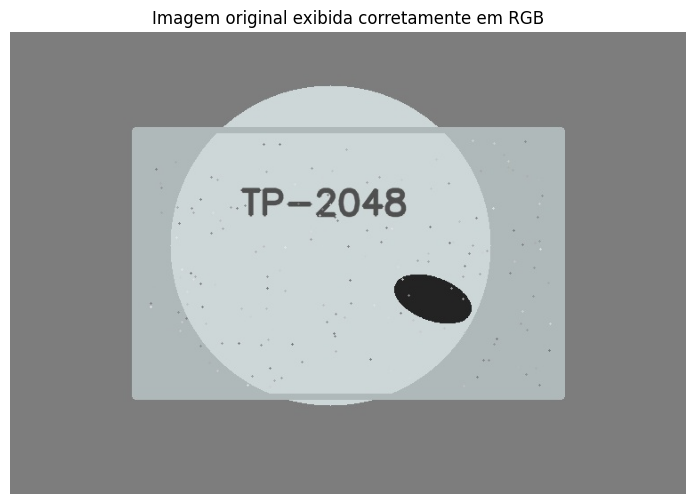

In [17]:
imagem_rgb = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(imagem_rgb)
plt.title("Imagem original exibida corretamente em RGB")
plt.axis("off")
plt.show()

In [18]:
altura, largura, canais = imagem_bgr.shape

tipo_dado = imagem_bgr.dtype
valor_minimo = imagem_bgr.min()
valor_maximo = imagem_bgr.max()
valor_medio = imagem_bgr.mean()

print("PROPRIEDADES DA IMAGEM")
print("Altura em pixels:", altura)
print("Largura em pixels:", largura)
print("Número de canais:", canais)
print("Tipo de dado:", tipo_dado)
print("Valor mínimo de pixel:", valor_minimo)
print("Valor máximo de pixel:", valor_maximo)
print("Valor médio dos pixels:", round(float(valor_medio), 2))

amostra_pixels = imagem_bgr[0:5, 0:5]
print("\nAmostra 5x5 de pixels no canto superior esquerdo:")
print(amostra_pixels)

PROPRIEDADES DA IMAGEM
Altura em pixels: 520
Largura em pixels: 760
Número de canais: 3
Tipo de dado: uint8
Valor mínimo de pixel: 27
Valor máximo de pixel: 235
Valor médio dos pixels: 152.85

Amostra 5x5 de pixels no canto superior esquerdo:
[[[125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]]

 [[125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]
  [125 125 125]]]


Formato da imagem colorida: (520, 760, 3)
Formato da imagem em escala de cinza: (520, 760)
Valor mínimo em cinza: 27
Valor máximo em cinza: 231


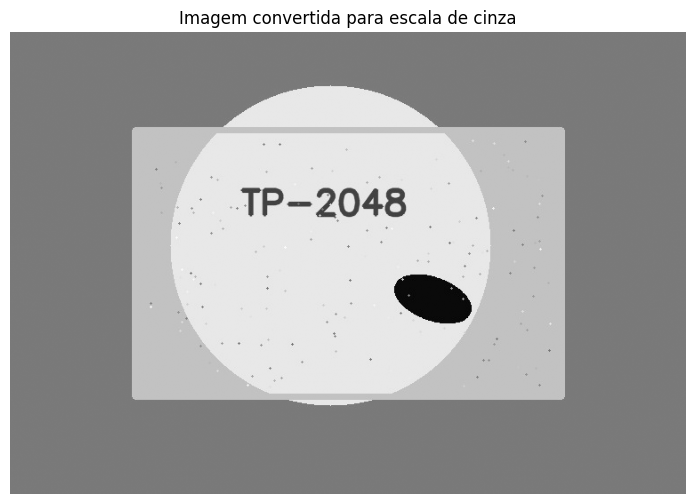

In [19]:
imagem_cinza = cv2.cvtColor(imagem_bgr, cv2.COLOR_BGR2GRAY)

print("Formato da imagem colorida:", imagem_bgr.shape)
print("Formato da imagem em escala de cinza:", imagem_cinza.shape)
print("Valor mínimo em cinza:", imagem_cinza.min())
print("Valor máximo em cinza:", imagem_cinza.max())

plt.figure(figsize=(10, 6))
plt.imshow(imagem_cinza, cmap="gray")
plt.title("Imagem convertida para escala de cinza")
plt.axis("off")
plt.show()

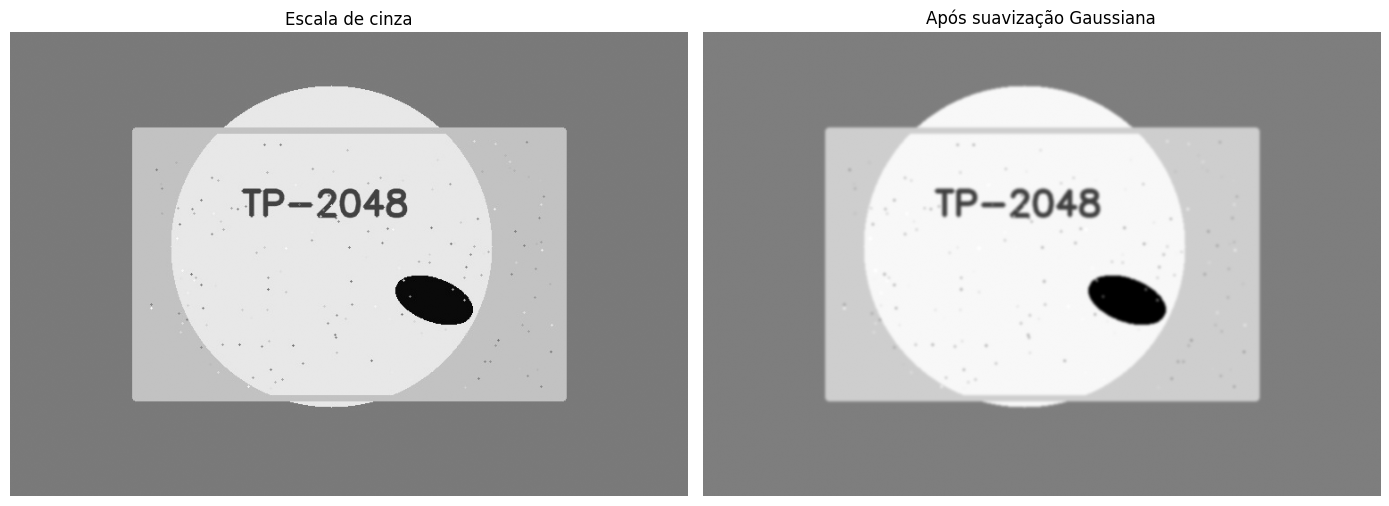

In [25]:
imagem_suavizada = cv2.GaussianBlur(imagem_cinza, (7, 7), 0)

fig, eixos = plt.subplots(1, 2, figsize=(14, 5))

eixos[0].imshow(imagem_cinza, cmap="gray")
eixos[0].set_title("Escala de cinza")
eixos[0].axis("off")

eixos[1].imshow(imagem_suavizada, cmap="gray")
eixos[1].set_title("Após suavização Gaussiana")
eixos[1].axis("off")

plt.tight_layout()
plt.show()

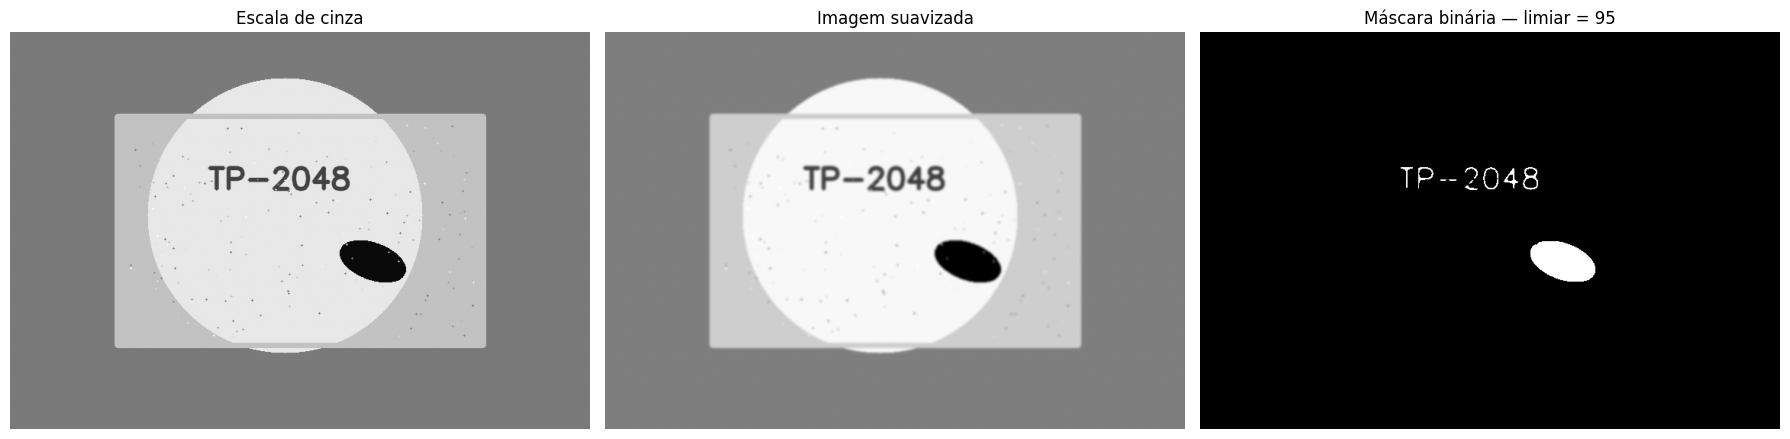

In [26]:
valor_limiar = 95

_, mascara_binaria = cv2.threshold(
    imagem_suavizada,
    valor_limiar,
    255,
    cv2.THRESH_BINARY_INV
)

fig, eixos = plt.subplots(1, 3, figsize=(18, 5))

eixos[0].imshow(imagem_cinza, cmap="gray")
eixos[0].set_title("Escala de cinza")
eixos[0].axis("off")

eixos[1].imshow(imagem_suavizada, cmap="gray")
eixos[1].set_title("Imagem suavizada")
eixos[1].axis("off")

eixos[2].imshow(mascara_binaria, cmap="gray")
eixos[2].set_title(f"Máscara binária — limiar = {valor_limiar}")
eixos[2].axis("off")

plt.tight_layout()
plt.show()

Quantidade de regiões relevantes detectadas: 3
Regiões detectadas no formato (x, y, largura, altura, área):
(433, 274, 85, 53, 3243.0)
(423, 177, 20, 30, 428.0)
(371, 177, 20, 29, 438.5)


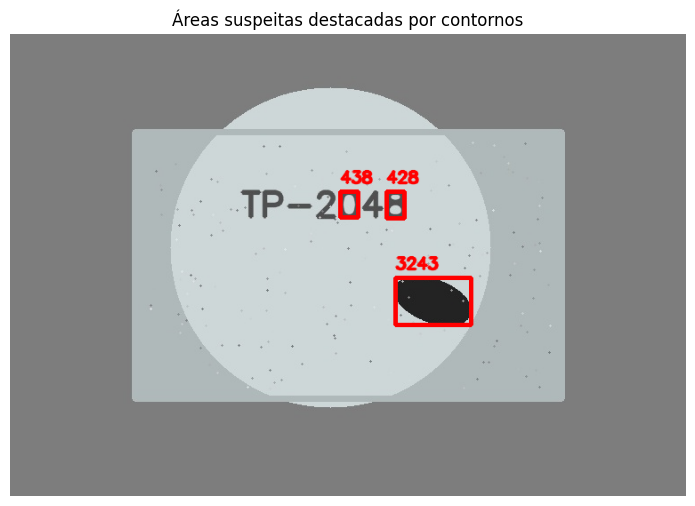

In [33]:
contornos, _ = cv2.findContours(
    mascara_binaria,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

imagem_detectada = imagem_rgb.copy()
area_minima = 300
regioes_detectadas = []

for contorno in contornos:
    area = cv2.contourArea(contorno)

    if area >= area_minima:
        x, y, w, h = cv2.boundingRect(contorno)
        regioes_detectadas.append((x, y, w, h, area))

        cv2.rectangle(imagem_detectada, (x, y), (x + w, y + h), (255, 0, 0), 3)
        cv2.putText(
            imagem_detectada,
            f"{area:.0f}",
            (x, max(y - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2,
            cv2.LINE_AA
        )

print("Quantidade de regiões relevantes detectadas:", len(regioes_detectadas))
print("Regiões detectadas no formato (x, y, largura, altura, área):")
for regiao in regioes_detectadas:
    print(regiao)

plt.figure(figsize=(10, 6))
plt.imshow(imagem_detectada)
plt.title("Áreas suspeitas destacadas por contornos")
plt.axis("off")
plt.show()

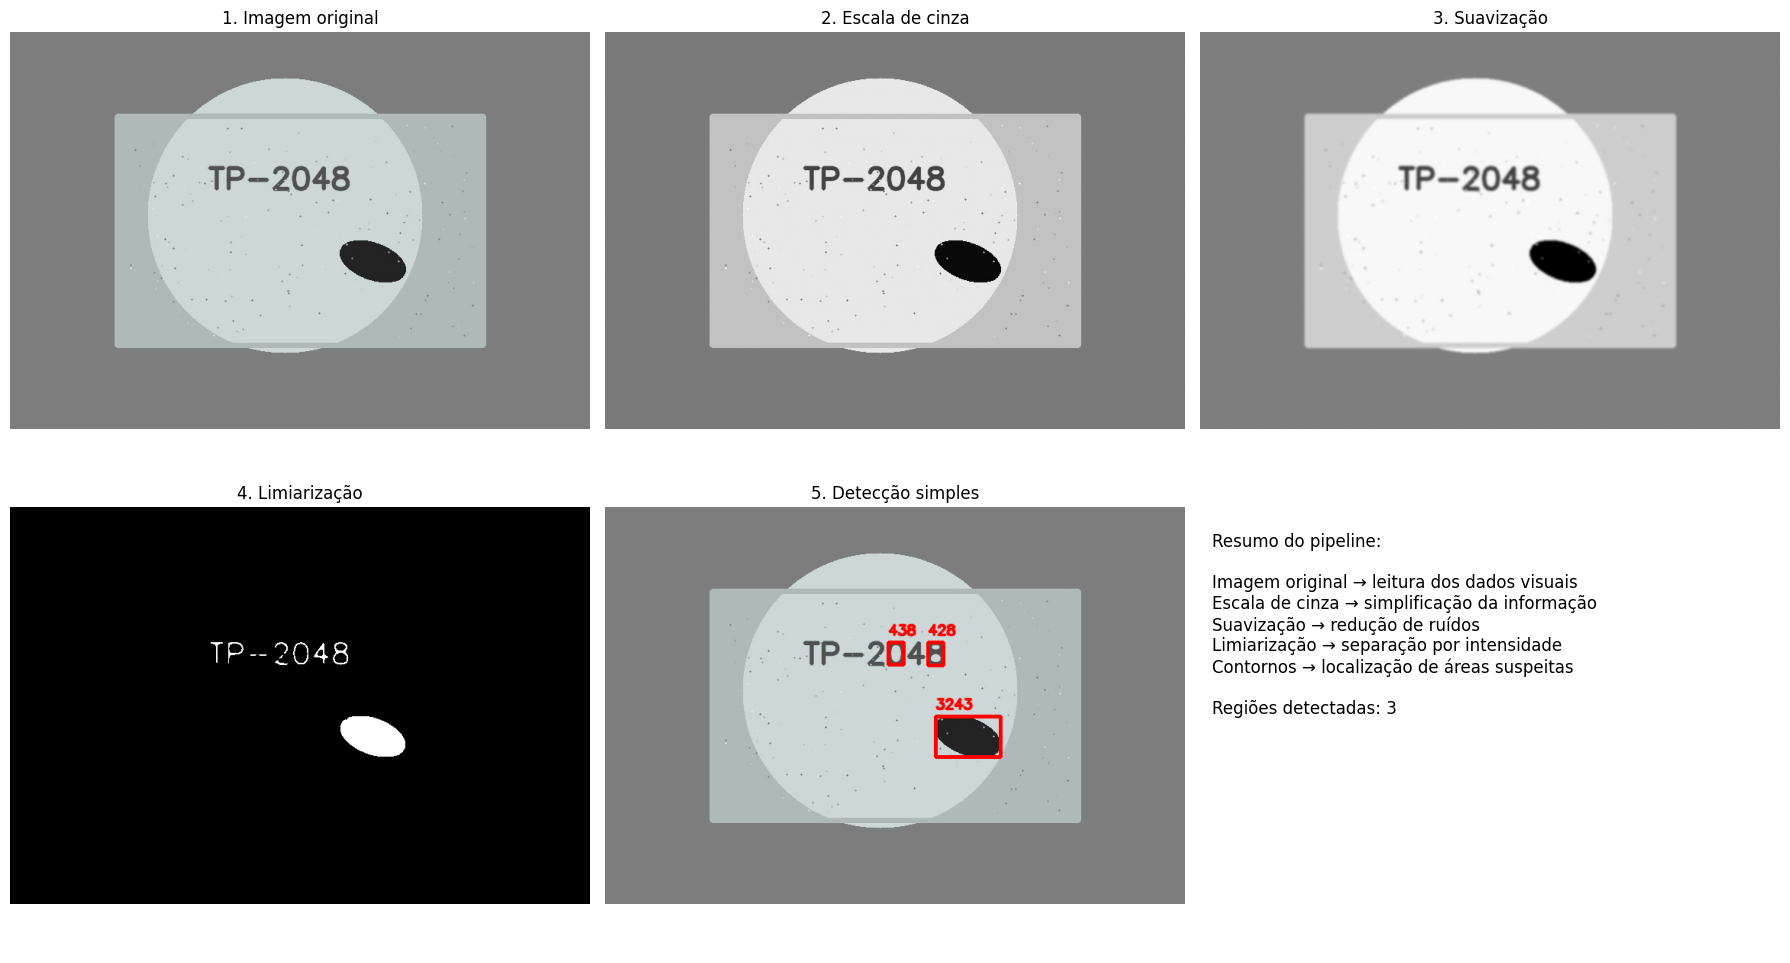

In [35]:
fig, eixos = plt.subplots(2, 3, figsize=(18, 10))

eixos[0, 0].imshow(imagem_rgb)
eixos[0, 0].set_title("1. Imagem original")
eixos[0, 0].axis("off")

eixos[0, 1].imshow(imagem_cinza, cmap="gray")
eixos[0, 1].set_title("2. Escala de cinza")
eixos[0, 1].axis("off")

eixos[0, 2].imshow(imagem_suavizada, cmap="gray")
eixos[0, 2].set_title("3. Suavização")
eixos[0, 2].axis("off")

eixos[1, 0].imshow(mascara_binaria, cmap="gray")
eixos[1, 0].set_title("4. Limiarização")
eixos[1, 0].axis("off")

eixos[1, 1].imshow(imagem_detectada)
eixos[1, 1].set_title("5. Detecção simples")
eixos[1, 1].axis("off")

eixos[1, 2].axis("off")
texto_resumo = (
    "Resumo do pipeline:\n\n"
    "Imagem original → leitura dos dados visuais\n"
    "Escala de cinza → simplificação da informação\n"
    "Suavização → redução de ruídos\n"
    "Limiarização → separação por intensidade\n"
    "Contornos → localização de áreas suspeitas\n\n"
    f"Regiões detectadas: {len(regioes_detectadas)}"
)
eixos[1, 2].text(0.02, 0.85, texto_resumo, fontsize=12, va="top")

plt.tight_layout()
plt.show()

In [24]:
pasta_resultados = Path("resultados_pratica")
pasta_resultados.mkdir(exist_ok=True)

cv2.imwrite(str(pasta_resultados / "01_original_bgr.png"), imagem_bgr)
cv2.imwrite(str(pasta_resultados / "02_escala_cinza.png"), imagem_cinza)
cv2.imwrite(str(pasta_resultados / "03_suavizada.png"), imagem_suavizada)
cv2.imwrite(str(pasta_resultados / "04_mascara_binaria.png"), mascara_binaria)

imagem_detectada_bgr = cv2.cvtColor(imagem_detectada, cv2.COLOR_RGB2BGR)
cv2.imwrite(str(pasta_resultados / "05_regioes_detectadas.png"), imagem_detectada_bgr)

print("Evidências salvas na pasta:", pasta_resultados.resolve())

Evidências salvas na pasta: C:\Users\Augusto\Curso_Senai\Visão Computacional\resultados_pratica
